# Checking students work for AI-generated solutions.

Final Score = w1 * StyleScore 
            + w2 * ComplexityScore
            + w3 * LLMScore
            + w4 * SimilarityScore
            + w5 * SemanticScore

## Style analysis 

In [4]:
import ast
import re

def extract_style_features(code: str, language: str = ".py"):

    if language == ".py":
        return _extract_python_features(code)
    
    elif language in [".cpp", ".cs", ".pas", ".c"]:
        return _extract_cpp_features(code)
    
    else:
        raise ValueError(f"Unsupported language: {language}")
    
def _extract_python_features(code: str):
    try:
        tree = ast.parse(code)
    except:
        return _fallback_features(code)

    var_names = []

    for node in ast.walk(tree):
        if isinstance(node, ast.Name):
            var_names.append(node.id)

    avg_len = sum(len(v) for v in var_names) / (len(var_names) + 1)

    comment_count = len(re.findall(r'#.*', code))
    lines = len(code.split('\n'))
    comment_density = comment_count / (lines + 1)

    return {
        "avg_var_length": avg_len,
        "comment_density": comment_density,
        "num_variables": len(var_names)
    }

def _fallback_features(code: str):
    words = re.findall(r'\b[a-zA-Z_]{2,}\b', code)

    avg_len = sum(len(w) for w in words) / (len(words) + 1)

    comment_count = len(re.findall(r'#|//', code))
    lines = len(code.split('\n'))

    return {
        "avg_var_length": avg_len,
        "comment_density": comment_count / (lines + 1),
        "num_variables": len(words)
    }

def _extract_cpp_features(code: str):
    # Remove strings (to avoid false positives)
    code_clean = re.sub(r'"(\\.|[^"])*"', '', code)

    # Variable detection (simple heuristic)
    var_pattern = r'\b(int|float|double|char|bool|long|auto|string)\s+([a-zA-Z_][a-zA-Z0-9_]*)'
    matches = re.findall(var_pattern, code_clean)

    var_names = [m[1] for m in matches]

    avg_len = sum(len(v) for v in var_names) / (len(var_names) + 1)

    # Comments: // and /* */
    single_comments = re.findall(r'//.*', code)
    multi_comments = re.findall(r'/\*[\s\S]*?\*/', code)

    comment_count = len(single_comments) + len(multi_comments)

    lines = len(code.split('\n'))
    comment_density = comment_count / (lines + 1)

    return {
        "avg_var_length": avg_len,
        "comment_density": comment_density,
        "num_variables": len(var_names)
    }

## Spacing

Ai has very consistent identation, perfect spacing with low variance.

In [5]:
def indentation_consistency(code: str, features: dict):
    indents = []

    for line in code.split('\n'):
        spaces = len(line) - len(line.lstrip(' '))
        if spaces > 0:
            indents.append(spaces)

    if not indents:
        features["indentation_consistency"] = 0.5
        return features

    variance = sum((x - sum(indents)/len(indents))**2 for x in indents) / len(indents)

    features["indentation_consistency"] = 1 / (1 + variance)  # higher = more consistent
    return features 

## Repetition

Ai often repeats patterns, same structure etc.

In [6]:
def repetition_score(code: str, features: dict):
    lines = [l.strip() for l in code.split('\n') if l.strip()]
    unique = set(lines)

    features["repetition_score"] = 1 - len(unique) / (len(lines) + 1)
    return features

## Overexplanation in comments

In [7]:
import re

def overexplanation_in_comments(code: str, extension: str, features: dict):
    if extension == ".py":
        comments = re.findall(r'#.*', code)
    else:
        comments = re.findall(r'//.*|/\*[\s\S]*?\*/', code)

    overexplained = sum(len(c.split()) for c in comments) / len(comments) if comments else 0
    features["overexplanation_score"] = overexplained 
    return features

## All together

In [8]:
def analyze_code_style(code: str, language: str = ".py"):
    features = extract_style_features(code, language)
    features = indentation_consistency(code, features)
    features = repetition_score(code, features)
    features = overexplanation_in_comments(code, language, features)
    return features

## Go over all files and check

Error reading 2026-05-02 07-20-24.877700, tun_20_06, task_2026_14, Scored (6.0 - 100.0), task_2026_14.py: 'charmap' codec can't decode byte 0x8f in position 418: character maps to <undefined>
Error reading 2026-05-02 07-24-03.965795, tun_20_06, task_2026_14, Scored (6.0 - 100.0), task_2026_14.py: 'charmap' codec can't decode byte 0x8f in position 547: character maps to <undefined>
Error reading 2026-05-02 07-29-26.418949, tun_20_06, task_2026_12, Scored (52.0 - 100.0), task_2026_12.py: 'charmap' codec can't decode byte 0x81 in position 105: character maps to <undefined>
Error reading 2026-05-02 07-30-52.212384, tun_20_06, task_2026_12, Scored (52.0 - 100.0), task_2026_12.py: 'charmap' codec can't decode byte 0x81 in position 105: character maps to <undefined>
Error reading 2026-05-02 07-31-15.584430, tun_20_06, task_2026_14, Scored (6.0 - 100.0), task_2026_14.py: 'charmap' codec can't decode byte 0x8f in position 547: character maps to <undefined>
Error reading 2026-05-02 07-31-19.5811

<unknown>:3: SyntaxWarning: invalid decimal literal
C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_26812\407967511.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


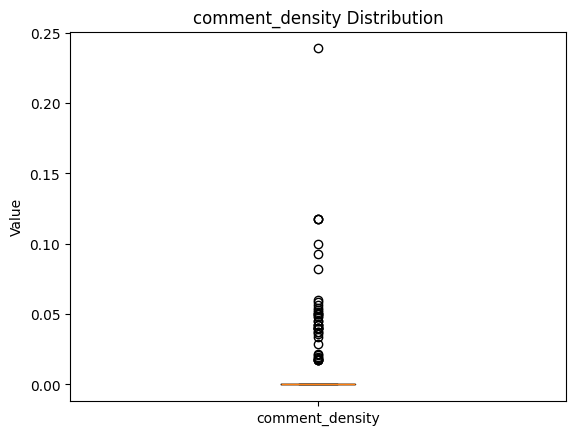

C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_26812\407967511.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


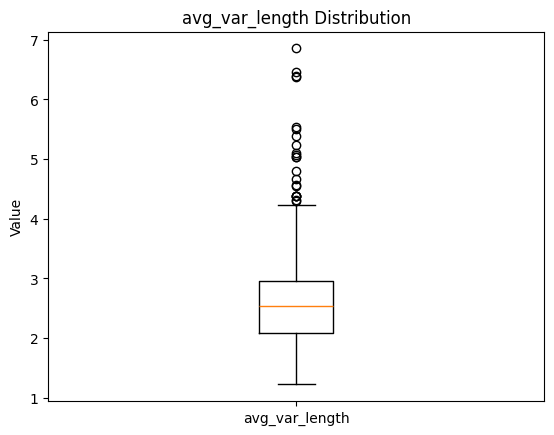

C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_26812\407967511.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


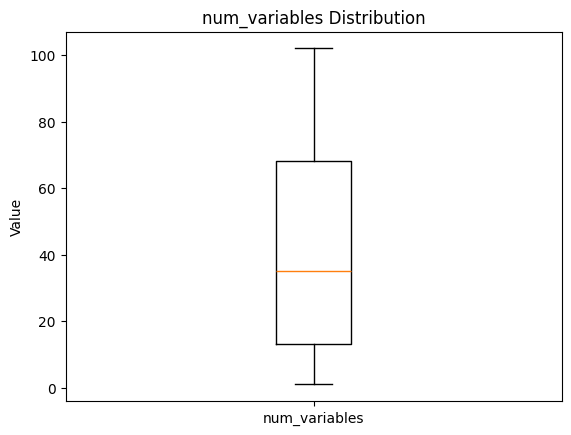

C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_26812\407967511.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


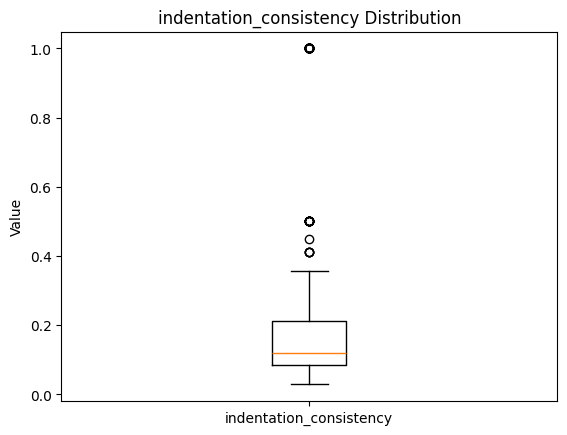

C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_26812\407967511.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


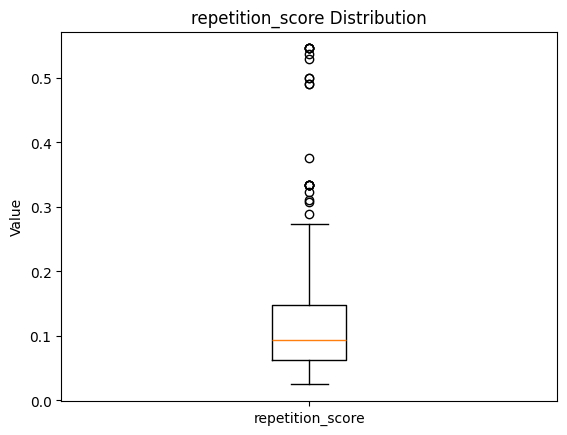

C:\Users\vmelnyk2\AppData\Local\Temp\ipykernel_26812\407967511.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[feature_name])


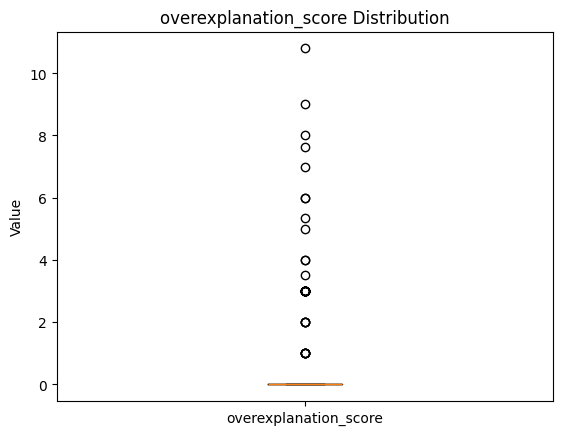

Outliers in comment_density:
2026-05-02 07-14-11.715144, sl16, task_2026_12, Scored (52.0 - 100.0), task_2026_12.cpp (nickname: sl16) - comment_density: 0.06
2026-05-02 07-17-06.141948, NotNiure, task_2026_11, Scored (0.0 - 100.0), task_2026_11.py (nickname: NotNiure) - comment_density: 0.11764705882352941
2026-05-02 07-18-18.899900, NotNiure, task_2026_15, Scored (60.0 - 100.0), task_2026_15.py (nickname: NotNiure) - comment_density: 0.11764705882352941
2026-05-02 07-23-38.826129, NotNiure, task_2026_15, Scored (100.0 - 100.0), task_2026_15.py (nickname: NotNiure) - comment_density: 0.1
2026-05-02 07-37-03.089403, sl16, task_2026_15, Scored (100.0 - 100.0), task_2026_15.cpp (nickname: sl16) - comment_density: 0.04477611940298507
2026-05-02 07-40-27.150259, NotNiure, task_2026_13, Scored (60.0 - 100.0), task_2026_13.py (nickname: NotNiure) - comment_density: 0.05
2026-05-02 07-42-04.405770, NotNiure, task_2026_13, Scored (60.0 - 100.0), task_2026_13.py (nickname: NotNiure) - comment_de

In [9]:
import os

folder_path = os.path.join(os.getcwd(), "submissions")

student_nicknames = set()
filenames = os.listdir(folder_path)

for filename in filenames:
    nickname = filename.split(",")[1].strip()
    student_nicknames.add(nickname)

# print("Unique student nicknames:")
# for nickname in student_nicknames:
#     print(nickname)

feture_list = []

for file_name in filenames:
    nickname = file_name.split(",")[1].strip()
    
    try:
        file_content = open(os.path.join(folder_path, file_name)).read()
    except Exception as e:
        print(f"Error reading {file_name}: {e}")
        continue

    extension = os.path.splitext(file_name)[1]
    features = analyze_code_style(file_content, language=extension)

    features["nickname"] = nickname
    features["file_name"] = file_name
    feture_list.append(features)

import numpy as np
import matplotlib.pyplot as plt

def display_box_plot(feature_name):
    data = [f[feature_name] for f in feture_list]
    plt.boxplot(data, labels=[feature_name])
    plt.title(f'{feature_name} Distribution')
    plt.ylabel('Value')
    plt.show()

display_box_plot("comment_density")
display_box_plot("avg_var_length")
display_box_plot("num_variables")
display_box_plot("indentation_consistency")
display_box_plot("repetition_score")
display_box_plot("overexplanation_score")

def detect_outliers(feature_name):
    data = np.array([f[feature_name] for f in feture_list])
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = [f for f in feture_list if f[feature_name] < lower_bound or f[feature_name] > upper_bound]
    return outliers

print("Outliers in comment_density:")
outliers_comment_density = detect_outliers("comment_density")
for o in outliers_comment_density:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - comment_density: {o['comment_density']}")

print("\nOutliers in avg_var_length:")
outliers_avg_var_length = detect_outliers("avg_var_length")
for o in outliers_avg_var_length:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - avg_var_length: {o['avg_var_length']}")

print("\nOutliers in num_variables:")
outliers_num_variables = detect_outliers("num_variables")
for o in outliers_num_variables:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - num_variables: {o['num_variables']}")
# print(feture_list)

print("\nOutliers in indentation_consistency:")
outliers_indentation_consistency = detect_outliers("indentation_consistency")
for o in outliers_indentation_consistency:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - indentation_consistency: {o['indentation_consistency']}")

print("\nOutliers in repetition_score:")
outliers_repetition_score = detect_outliers("repetition_score")
for o in outliers_repetition_score:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - repetition_score: {o['repetition_score']}")

print("\nOutliers in repetition_score:")
outliers_repetition_score = detect_outliers("repetition_score")
for o in outliers_repetition_score:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - repetition_score: {o['repetition_score']}")

print("\nOutliers in overexplanation_score:")
outliers_overexplanation_score = detect_outliers("overexplanation_score")
for o in outliers_overexplanation_score:
    print(f"{o['file_name']} (nickname: {o['nickname']}) - overexplanation_score: {o['overexplanation_score']}")

# outliers = set([o["file_name"] for o in outliers_comment_density]).intersection(set([o["file_name"] for o in outliers_avg_var_length])) #+ set(outliers_num_variables)
# print("\nStudents with outliers in both comment_density and avg_var_length:")
# print(outliers)

outliers_json = {
    "comment_density": [o["file_name"] for o in outliers_comment_density],
    "avg_var_length": [o["file_name"] for o in outliers_avg_var_length],
    "num_variables": [o["file_name"] for o in outliers_num_variables],
    "indentation_consistency": [o["file_name"] for o in outliers_indentation_consistency],
    "repetition_score": [o["file_name"] for o in outliers_repetition_score],
    "overexplanation_score": [o["file_name"] for o in outliers_overexplanation_score]
}

import json
with open("outliers.json", "w") as f:
    json.dump(outliers_json, f, indent=4)

In [6]:
import json
import pandas as pd
from pathlib import Path

datasets_dir = Path.cwd() / 'datasets'
third = pd.read_csv(datasets_dir / 'third.csv')
solutions = pd.read_csv(datasets_dir / 'solutions.csv')

df = third.merge(solutions[['SolutionID','Language']], on='SolutionID', how='left')

# Filter out rows where Language is NaN
df_clean = df.dropna(subset=['Language'])

print(f"Rows with Language values: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

def lang_to_ext(lang):
    """Map language string to file extension."""
    if pd.isna(lang):
        return '.txt'
    l = str(lang).upper()
    token = l.split()[0]  # Take first token before space/version
    if 'PYTH' in token:
        return '.py'
    if 'C++' in token or 'CPP' in token:
        return '.cpp'
    if 'JAVA' in token:
        return '.java'
    if 'C#' in token or 'CS' in token:
        return '.cs'
    if 'PAS' in token:
        return '.pas'
    if token == 'C':
        return '.c'
    return '.txt'

# Run analyze_code_style on clean data
results = []
errors = []

i = 0
for idx, row in df_clean.iterrows():
    sol_id = row.get('SolutionID')
    code = str(row.get('Solutions', ''))
    lang = row.get('Language', '')
    ext = lang_to_ext(lang)
    
    try:
        features = analyze_code_style(code, language=ext)
        features['SolutionID'] = sol_id
        features['Language'] = lang
        features['FileExtension'] = ext
        results.append(features)

        i += 1
        if i >= 500:
            break
        
    except Exception as e:
        errors.append({
            'SolutionID': sol_id,
            'Language': lang,
            'Error': str(e)
        })

print(f"\nSuccessfully analyzed: {len(results)} solutions")
if errors:
    print(f"Errors encountered: {len(errors)}")

# Save results to JSON
with open('style_analysis_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("\nResults saved to style_analysis_results.json")

# Display sample results
if results:
    print(f"\nSample result (first solution):")
    print(json.dumps(results[0], indent=2))

Rows with Language values: 167988 (dropped 143861)

Successfully analyzed: 500 solutions
Errors encountered: 134

Results saved to style_analysis_results.json

Sample result (first solution):
{
  "avg_var_length": 2.0,
  "comment_density": 0.0,
  "num_variables": 4,
  "indentation_consistency": 1.0,
  "repetition_score": 0.16000000000000003,
  "overexplanation_score": 0,
  "SolutionID": "S11966595",
  "Language": "C++14",
  "FileExtension": ".cpp"
}


## Generating solutions via openAi

In [7]:
import os 
import re 
import time 
from pathlib import Path 
from dotenv import load_dotenv 
from openai import OpenAI
import random

load_dotenv()

num_submissions = 400
save_dir = "generated"
code_start = "###START###"
code_end = "###END###"

model = "gpt-4o"
api_key = os.getenv("OPEN_API_KEY")

client = OpenAI(api_key=api_key)

TOPICS = [ "dynamic programming", "graphs", "trees", "shortest path", "greedy algorithms", 
          "number theory", "combinatorics", "binary search", "segment trees", "disjoint set union", 
          "string algorithms", "hashing", "two pointers", "sliding window", "backtracking", "dfs", 
          "bfs", "minimum spanning tree", "topological sort", "game theory" ]
LANGUAGES = [".py", ".cpp"]

offset = 100
for i in range(num_submissions):
    topic = random.choice(TOPICS)
    language = random.choice(LANGUAGES)

    prompt = f"""Write a complete olympiad-style solution to programming problem in language {language}. Topic: {topic}. 
    Requirement: output code ONLY between: {code_start} and {code_end}. 
    
    Example: 
    
    {code_start}
    print("Hello World")
    {code_end}"""

    response = client.responses.create(model=model, input=prompt)

    text = response.output_text

    pattern = ( re.escape(code_start) + r"(.*?)" + re.escape(code_end) )
    result = ""
    match = re.search(pattern, text, re.DOTALL) 
    if not match:
        continue
    result = match.group(1).strip()
    
    file_name = os.path.join(save_dir, f"{offset + i}{language}")

    with open(file_name, "w", encoding="utf-8") as f:
        f.write(result)

    time.sleep(1)


In [9]:
import json
import pandas as pd
from pathlib import Path

folder_path = os.path.join(os.getcwd(), "generated")
filenames = os.listdir(folder_path)
feature_list = []

for file_name in filenames:
    try:
        file_content = open(os.path.join(folder_path, file_name)).read()
    except Exception as e:
        print(f"Error reading {file_name}: {e}")
        continue

    extension = os.path.splitext(file_name)[1]
    if extension not in [".py", ".cpp"]:
        print(f"Skipping unsupported file type: {file_name}")
        continue
    
    features = analyze_code_style(file_content, language=extension)

    features["file_name"] = file_name
    feature_list.append(features)

with open('style_analysis_results_gen.json', 'w', encoding='utf-8') as f:
    json.dump(feature_list, f, indent=2, ensure_ascii=False)

Skipping unsupported file type: todo.md


# Ansamble model to detect 

- load `style_analysis_results_gen.json` and `style_analysis_results.json` and perform ML analysis.

Number of generated submissions: 499
Number of real submissions: 500
Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       100
           1       0.97      0.95      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



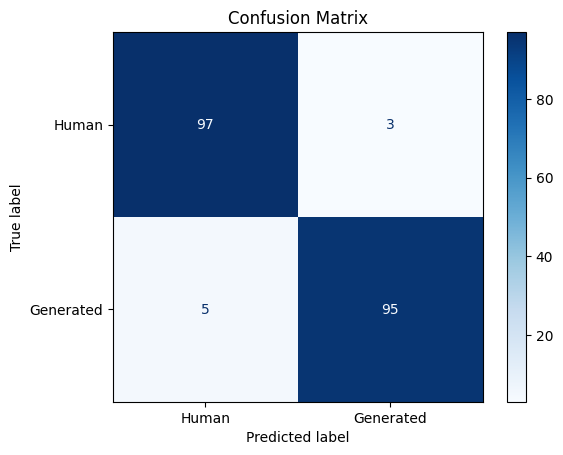

In [2]:
# count number of items
import json

filename_geneated = "style_analysis_results_gen.json"
filename_real = "style_analysis_results.json"

with open(filename_geneated, 'r', encoding='utf-8') as f:
    generated_data = json.load(f)

with open(filename_real, 'r', encoding='utf-8') as f:
    real_data = json.load(f)

print(f"Number of generated submissions: {len(generated_data)}")
print(f"Number of real submissions: {len(real_data)}")


# RANDOM FOREST CLASSIFIER
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

FEATURES = [
    "avg_var_length",
    "comment_density",
    "num_variables",
    "indentation_consistency",
    "repetition_score",
    "overexplanation_score"
]

def to_df(data, label):
    df = pd.DataFrame(data)
    df["label"] = label
    return df

df_gen = to_df(generated_data, 1)
df_human = to_df(real_data, 0)

df = pd.concat([df_gen, df_human], ignore_index=True)

X = df[FEATURES].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Human", "Generated"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


                   feature  importance
5    overexplanation_score    0.262930
1          comment_density    0.170008
0           avg_var_length    0.170006
3  indentation_consistency    0.142846
2            num_variables    0.136273
4         repetition_score    0.117937


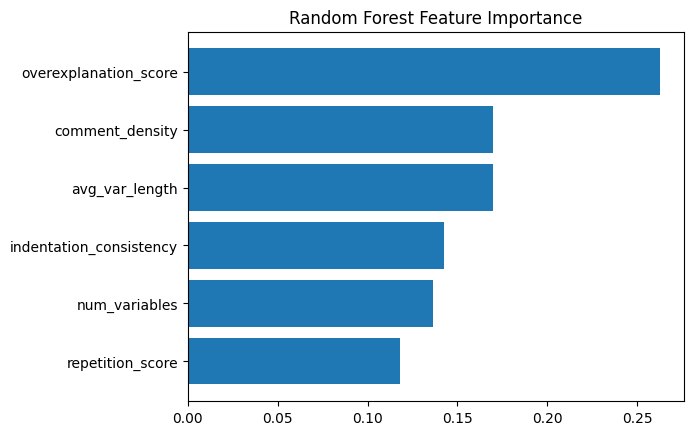

In [3]:
# RANDOM FOREST FEATURE IMPORTANCE
import pandas as pd
import matplotlib.pyplot as plt

feature_names = [
    "avg_var_length",
    "comment_density",
    "num_variables",
    "indentation_consistency",
    "repetition_score",
    "overexplanation_score"
]

importances = model.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(fi_df)

plt.figure()
plt.barh(fi_df["feature"], fi_df["importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.show()

In [12]:
import numpy as np

def detect_suspicious_items(model, data, threshold=0.6):
    df = pd.DataFrame(data)

    X = df[feature_names].values

    probs = model.predict_proba(X)[:, 1]  # probability of "generated"

    df["generated_prob"] = probs

    suspicious = df[df["generated_prob"] >= threshold]

    return suspicious[["file_name", "generated_prob"]]


import os

folder_path = os.path.join(os.getcwd(), "submissions")

student_nicknames = set()
filenames = os.listdir(folder_path)

for filename in filenames:
    nickname = filename.split(",")[1].strip()
    student_nicknames.add(nickname)

# print("Unique student nicknames:")
# for nickname in student_nicknames:
#     print(nickname)

feture_list = []

for file_name in filenames:
    nickname = file_name.split(",")[1].strip()
    
    try:
        file_content = open(os.path.join(folder_path, file_name)).read()
    except Exception as e:
        print(f"Error reading {file_name}: {e}")
        continue

    extension = os.path.splitext(file_name)[1]
    features = analyze_code_style(file_content, language=extension)

    features["nickname"] = nickname
    features["file_name"] = file_name
    feture_list.append(features)

# print(feture_list[:20])
suspicious_items = detect_suspicious_items(model, feture_list, threshold=0.6)
print("\nSuspicious items (probability >= 0.6):")
print(suspicious_items)

Error reading 2026-05-02 07-20-24.877700, tun_20_06, task_2026_14, Scored (6.0 - 100.0), task_2026_14.py: 'charmap' codec can't decode byte 0x8f in position 418: character maps to <undefined>
Error reading 2026-05-02 07-24-03.965795, tun_20_06, task_2026_14, Scored (6.0 - 100.0), task_2026_14.py: 'charmap' codec can't decode byte 0x8f in position 547: character maps to <undefined>
Error reading 2026-05-02 07-29-26.418949, tun_20_06, task_2026_12, Scored (52.0 - 100.0), task_2026_12.py: 'charmap' codec can't decode byte 0x81 in position 105: character maps to <undefined>
Error reading 2026-05-02 07-30-52.212384, tun_20_06, task_2026_12, Scored (52.0 - 100.0), task_2026_12.py: 'charmap' codec can't decode byte 0x81 in position 105: character maps to <undefined>
Error reading 2026-05-02 07-31-15.584430, tun_20_06, task_2026_14, Scored (6.0 - 100.0), task_2026_14.py: 'charmap' codec can't decode byte 0x8f in position 547: character maps to <undefined>
Error reading 2026-05-02 07-31-19.5811

<unknown>:3: SyntaxWarning: invalid decimal literal


## OTHER APPROACHES: XGBOOST, SVM, LSTM

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       100
           1       0.96      0.95      0.95       100

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200



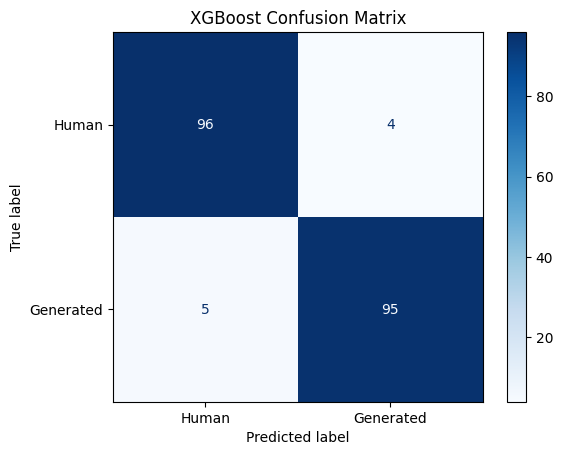

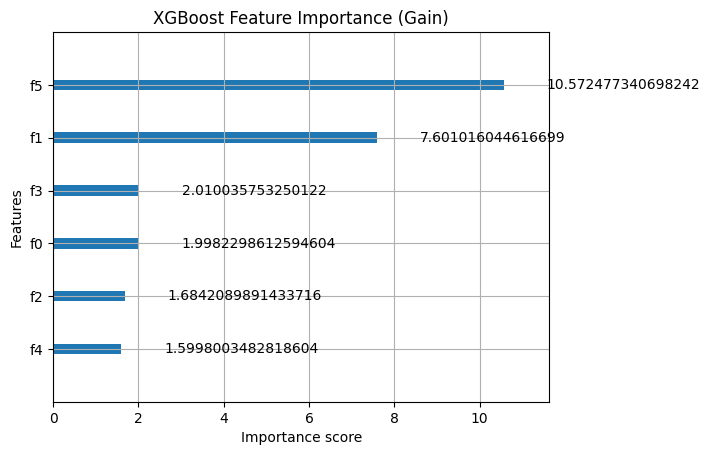

In [14]:
# XGBOOST

import json
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import xgboost as xgb
import matplotlib.pyplot as plt


FEATURES = [
    "avg_var_length",
    "comment_density",
    "num_variables",
    "indentation_consistency",
    "repetition_score",
    "overexplanation_score"
]


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


generated = load_json("style_analysis_results_gen.json")
human = load_json("style_analysis_results.json")

def to_df(data, label):
    df = pd.DataFrame(data)
    df["label"] = label
    return df


df = pd.concat([
    to_df(generated, 1),
    to_df(human, 0)
], ignore_index=True)

X = df[FEATURES].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["Human", "Generated"])
disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

import matplotlib.pyplot as plt

xgb.plot_importance(model, importance_type="gain")
plt.title("XGBoost Feature Importance (Gain)")
plt.show()

              precision    recall  f1-score   support

           0       0.91      0.90      0.90       100
           1       0.90      0.91      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200



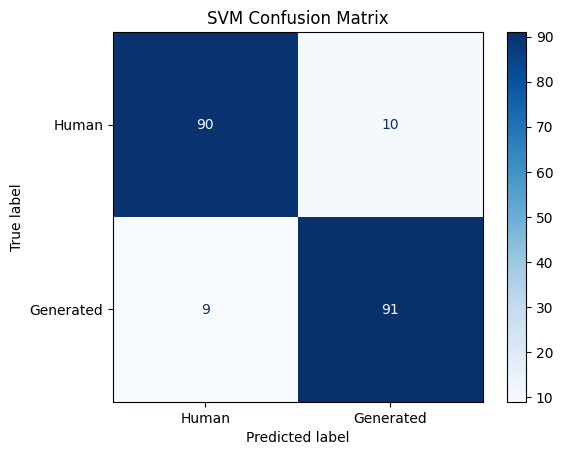

In [16]:
# SVM
import json
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

FEATURES = [
    "avg_var_length",
    "comment_density",
    "num_variables",
    "indentation_consistency",
    "repetition_score",
    "overexplanation_score"
]


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


generated = load_json("style_analysis_results_gen.json")
human = load_json("style_analysis_results.json")


def to_df(data, label):
    df = pd.DataFrame(data)
    df["label"] = label
    return df


df = pd.concat([
    to_df(generated, 1),
    to_df(human, 0)
], ignore_index=True)

X = df[FEATURES]
y = df["label"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

from sklearn.metrics import classification_report

y_pred = svm_model.predict(X_test)

print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "Generated"]
)

disp.plot(cmap="Blues")

plt.title("SVM Confusion Matrix")
plt.show()

Epoch 1/50  Loss=0.6065
Epoch 2/50  Loss=0.4176
Epoch 3/50  Loss=0.3517
Epoch 4/50  Loss=0.3264
Epoch 5/50  Loss=0.3116
Epoch 6/50  Loss=0.2944
Epoch 7/50  Loss=0.2786
Epoch 8/50  Loss=0.2630
Epoch 9/50  Loss=0.2487
Epoch 10/50  Loss=0.2493
Epoch 11/50  Loss=0.2266
Epoch 12/50  Loss=0.2206
Epoch 13/50  Loss=0.2118
Epoch 14/50  Loss=0.2139
Epoch 15/50  Loss=0.2022
Epoch 16/50  Loss=0.1944
Epoch 17/50  Loss=0.1926
Epoch 18/50  Loss=0.1895
Epoch 19/50  Loss=0.1841
Epoch 20/50  Loss=0.1842
Epoch 21/50  Loss=0.1868
Epoch 22/50  Loss=0.1750
Epoch 23/50  Loss=0.1706
Epoch 24/50  Loss=0.1676
Epoch 25/50  Loss=0.1621
Epoch 26/50  Loss=0.1596
Epoch 27/50  Loss=0.1609
Epoch 28/50  Loss=0.1551
Epoch 29/50  Loss=0.1513
Epoch 30/50  Loss=0.1502
Epoch 31/50  Loss=0.1508
Epoch 32/50  Loss=0.1476
Epoch 33/50  Loss=0.1444
Epoch 34/50  Loss=0.1518
Epoch 35/50  Loss=0.1458
Epoch 36/50  Loss=0.1363
Epoch 37/50  Loss=0.1363
Epoch 38/50  Loss=0.1296
Epoch 39/50  Loss=0.1411
Epoch 40/50  Loss=0.1290
Epoch 41/

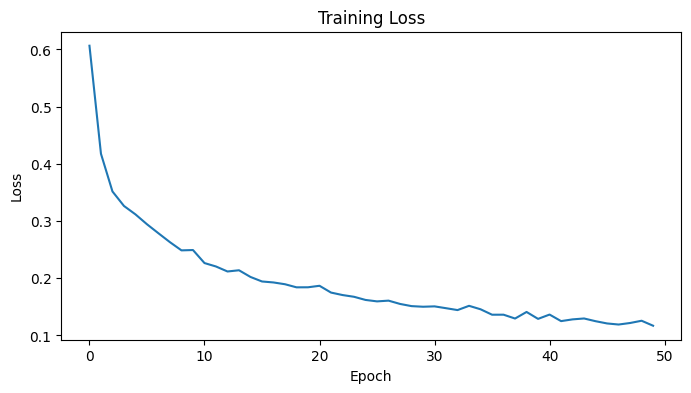

              precision    recall  f1-score   support

           0       0.98      0.92      0.95       100
           1       0.92      0.98      0.95       100

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



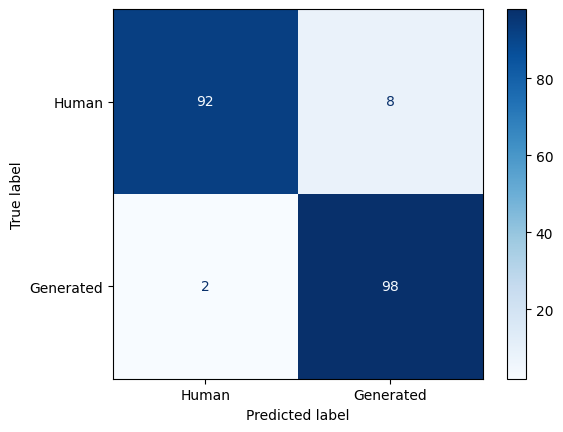

In [17]:
# CNN
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

FEATURES = [
    "avg_var_length",
    "comment_density",
    "num_variables",
    "indentation_consistency",
    "repetition_score",
    "overexplanation_score"
]


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


generated = load_json("style_analysis_results_gen.json")
human = load_json("style_analysis_results.json")


def to_df(data, label):
    df = pd.DataFrame(data)
    df["label"] = label
    return df


df = pd.concat([
    to_df(generated, 1),
    to_df(human, 0)
], ignore_index=True)

X = df[FEATURES].values.astype(np.float32)
y = df["label"].values.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class SubmissionDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
train_loader = DataLoader(
    SubmissionDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    SubmissionDataset(X_test, y_test),
    batch_size=32
)

class CNNClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=16,
            kernel_size=2
        )

        self.conv2 = nn.Conv1d(
            16,
            32,
            kernel_size=2
        )

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(32 * 4, 64)

        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):

        x = x.unsqueeze(1)

        x = self.relu(self.conv1(x))

        x = self.relu(self.conv2(x))

        x = x.flatten(1)

        x = self.relu(self.fc1(x))

        return self.fc2(x)
    
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CNNClassifier().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 50

history = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    history.append(epoch_loss)

    print(
        f"Epoch {epoch+1}/{epochs}  Loss={epoch_loss:.4f}"
    )

plt.figure(figsize=(8,4))

plt.plot(history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

model.eval()

predictions = []
truth = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        logits = model(X_batch)

        pred = logits.argmax(1)

        predictions.extend(pred.cpu().numpy())

        truth.extend(y_batch.numpy())

print(classification_report(
    truth,
    predictions
))

cm = confusion_matrix(
    truth,
    predictions
)

disp = ConfusionMatrixDisplay(
    cm,
    display_labels=[
        "Human",
        "Generated"
    ]
)

disp.plot(cmap="Blues")

plt.show()

We now have to json files with data

**TODO:**
- Compare mean values
- Compare outlier count via Mahalonobis dist./ Isolation Forest
- Do visual comparison  